### Modelado y Creación del Árbol de Decisión

El objetivo es analizar los datos y aplicar técnicas de minería de datos para resolver un problema de clasificación o segmentación.

In [36]:
# =========================================
# 📦 IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================
# 📂 CARGA DE DATOS
# =========================================
df = pd.read_csv('../dataset/cleaned/cleaned_dataset.csv')

# Vista inicial
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [37]:
# =========================================
# ⚠️ VERIFICAR VARIABLES CATEGÓRICAS
# =========================================

cat_cols = df.select_dtypes(include='object').columns
print("\nColumnas categóricas:", cat_cols)

### Codificación de variables categóricas

""" Los modelos de machine learning trabajan con datos numéricos, por lo que fue necesario 
transformar las variables categóricas para poder entrenar el modelo correctamente. """

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('---> Variables categóricas codificadas correctamente.')

print("\nTipos de datos después de encoding:")
print(df.dtypes)


Columnas categóricas: Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')
---> Variables categóricas codificadas correctamente.

Tipos de datos después de encoding:
job_title           int64
experience_years    int64
education_level     int64
skills_count        int64
industry            int64
company_size        int64
location            int64
remote_work         int64
certifications      int64
salary              int64
dtype: object


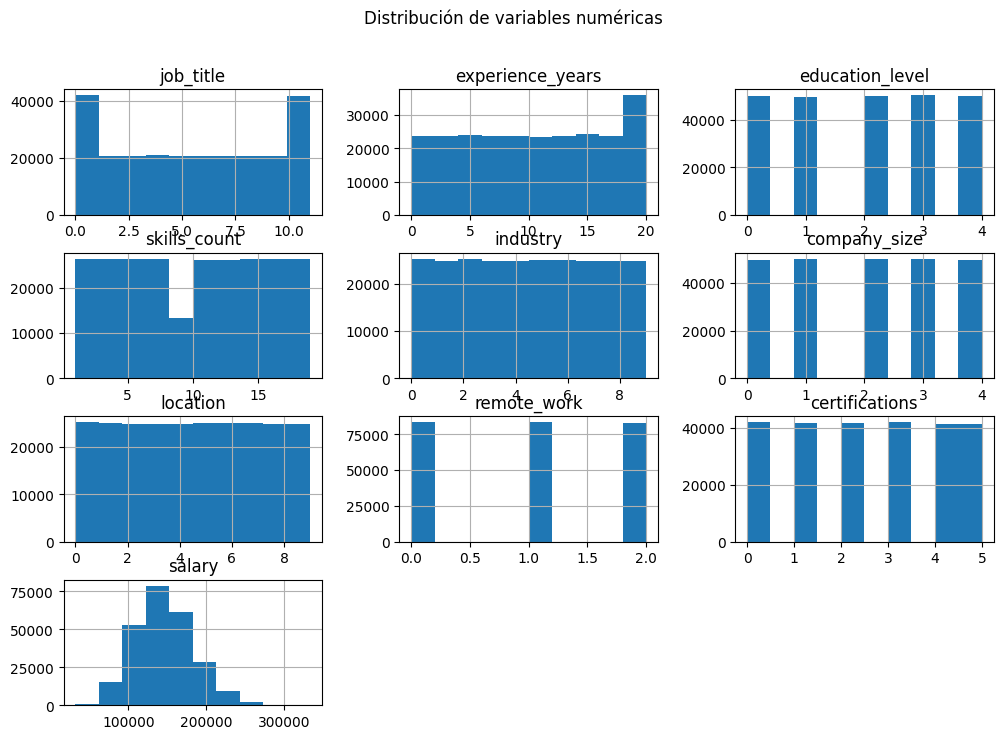

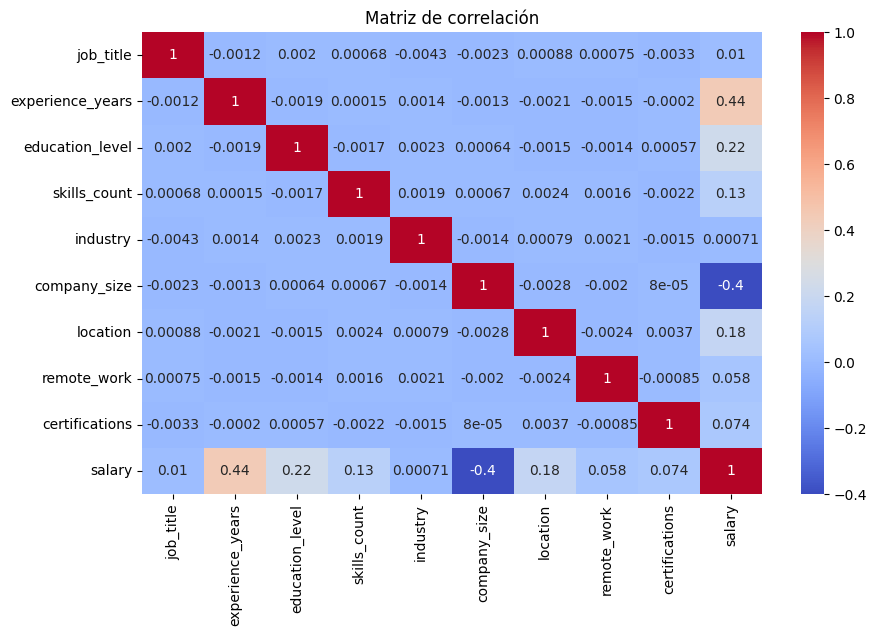

In [38]:
# =========================================
# 📊 ANÁLISIS EXPLORATORIO (EDA)
# =========================================

# Histogramas
df.hist(figsize=(12,8))
plt.suptitle("Distribución de variables numéricas")
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


In [39]:
# =========================================
# ⚖️ ESCALADO DE DATOS
# =========================================
scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

# =========================================
# 🎯 SEPARACIÓN DE VARIABLES
# =========================================
X = df.drop('salary', axis=1)
y = df['salary']

In [40]:
# =========================================
# ✂️ DIVISIÓN TRAIN / TEST
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [41]:
# =========================================
# 🌳 MODELO: ÁRBOL DE DECISIÓN
# =========================================
model = DecisionTreeRegressor(
    max_depth=5,      # Controla sobreajuste
    random_state=42
)

# Entrenar modelo (YA NO DEBE FALLAR)
model.fit(X_train, y_train)

# =========================================
# 🔮 PREDICCIONES
# =========================================
y_pred = model.predict(X_test)

# =========================================
# 📏 EVALUACIÓN
# =========================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nResultados del modelo:")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)


Resultados del modelo:
MAE: 0.5033154495583846
MSE: 0.39419070228999686
R2: 0.603118981102588


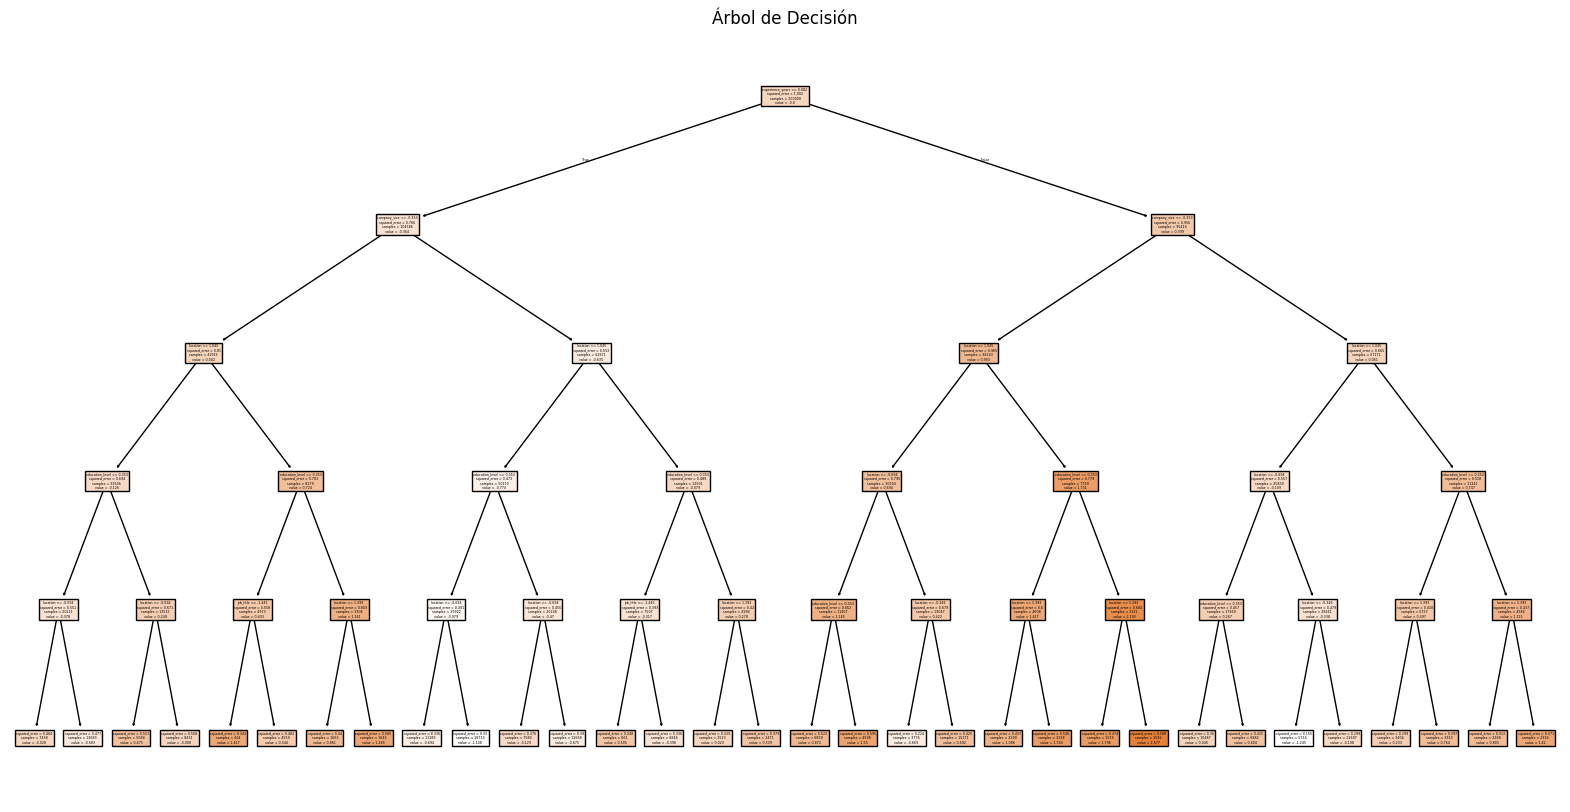

In [42]:
# =========================================
# 🌳 VISUALIZACIÓN DEL ÁRBOL
# =========================================
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.title("Árbol de Decisión")
plt.show()

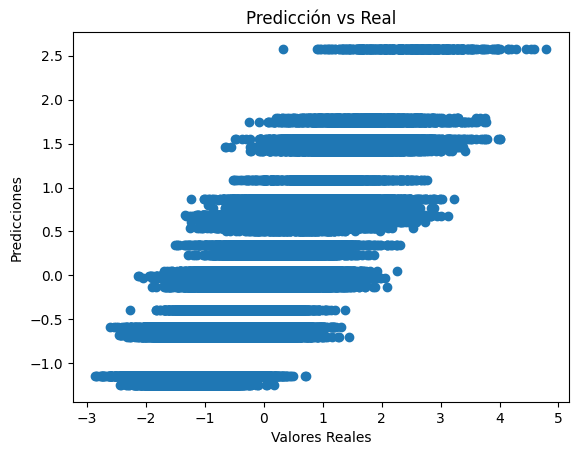

In [43]:
# =========================================
# 📈 PREDICCIÓN VS REAL
# =========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Real")
plt.show()